In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [3]:
df = pd.read_csv('/content/pakwheels_clean.csv')

In [4]:
df.head(1)

,year,price,Km_travelled,fuel_type,transmission,city,color,assembly,engine,body_type,interior_scores,exterior_scores,safety_scores,comfort_scores,company
0,2020,0.64,50000,Petrol,Automatic,Karachi,White,Imported,2000.0,Crossover,34.0,30.0,38.0,42.0,KIA


# Outlier Detection

# Km Travlled

<Axes: xlabel='Km_travelled', ylabel='Count'>

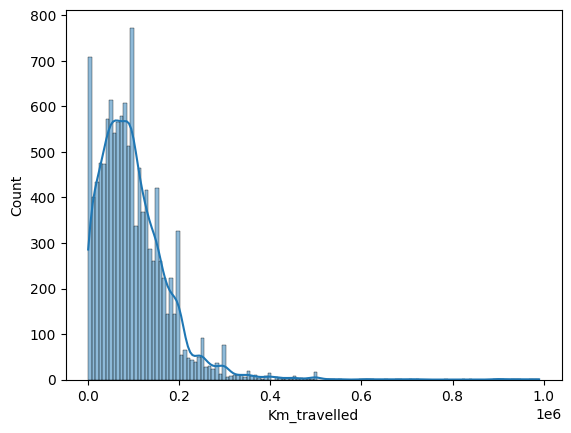

In [5]:
sns.histplot(df['Km_travelled'],kde=True)

<Axes: ylabel='Km_travelled'>

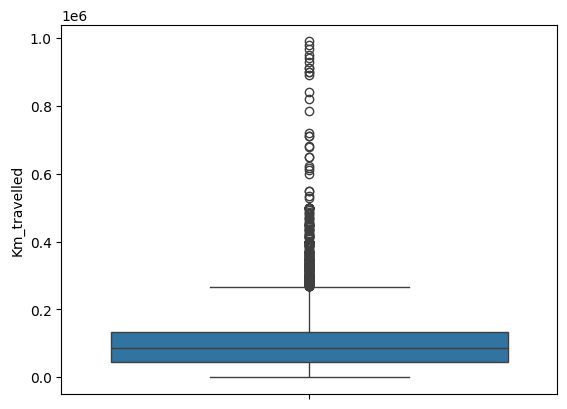

In [6]:
sns.boxplot(df['Km_travelled'])

In [7]:
q1 = df['Km_travelled'].quantile(0.25)
q3 = df['Km_travelled'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1  - iqr * 1.5
upper_bound = q3  + iqr * 1.5

In [8]:
df['Km_travelled'].describe()

,Km_travelled
count,11917.000000
mean,98304.923806
std,79159.935562
min,1.000000
25%,45000.000000
50%,85000.000000
75%,134000.000000
max,990000.000000


In [9]:
df[df['Km_travelled'] > 400000].shape

(79, 15)

In [10]:
np.log1p(df['Km_travelled']).describe()

,Km_travelled
count,11917.000000
mean,10.935806
std,1.753990
min,0.693147
25%,10.714440
50%,11.350418
75%,11.805603
max,13.805461


<Axes: xlabel='Km_travelled', ylabel='Count'>

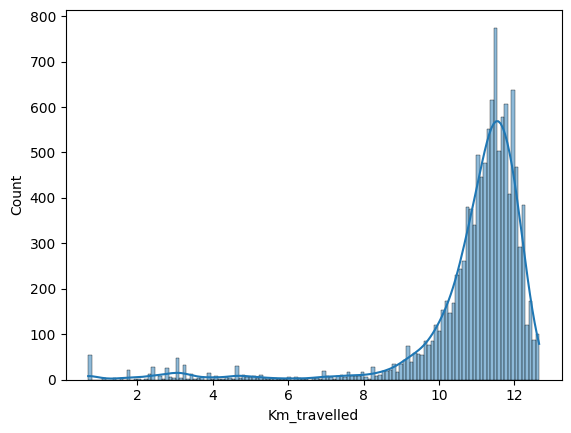

In [11]:
sns.histplot(np.log1p(df[df['Km_travelled'] < 315369]['Km_travelled']),kde=True)

<Axes: xlabel='Km_travelled', ylabel='Count'>

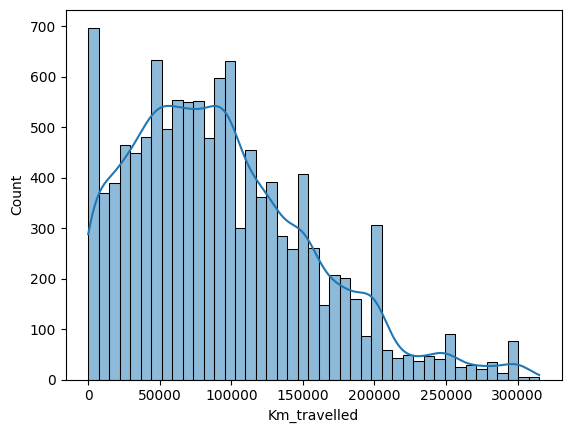

In [12]:
sns.histplot(df[df['Km_travelled'] < 315369]['Km_travelled'],kde=True)

<Axes: xlabel='Km_travelled', ylabel='Count'>

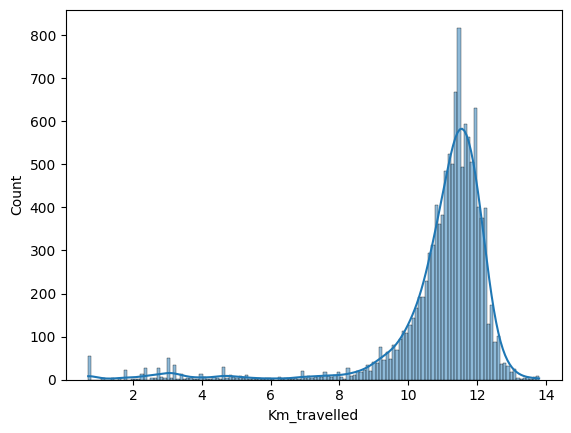

In [13]:
sns.histplot(np.log1p(df['Km_travelled']),kde=True)

In [14]:
df['Km_travelled'].describe()

,Km_travelled
count,11917.000000
mean,98304.923806
std,79159.935562
min,1.000000
25%,45000.000000
50%,85000.000000
75%,134000.000000
max,990000.000000


In [24]:
df[(df['Km_travelled'] < lower_bound) |  (df['Km_travelled'] > upper_bound)].sample(2)

,year,price,Km_travelled,fuel_type,transmission,city,color,assembly,engine,body_type,interior_scores,exterior_scores,safety_scores,comfort_scores,company
6144,2014,0.38,275648,Hybrid,Automatic,Islamabad,Silver,Imported,1500.0,Mini Van,18.0,6.0,34.0,29.0,Honda
1388,1993,0.06,433042,Petrol,Manual,Islamabad,Grey,Local,1500.0,Sedan,10.0,0.0,0.0,2.0,Daewoo


# In this i see that old cars have more km_travelled so we cant treat them as outliers

# Engine

In [28]:
q1 = df['engine'].quantile(0.25)
q3 = df['engine'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1  - iqr * 1.5
upper_bound = q3  + iqr * 1.5

In [43]:
df.loc[11743,'engine'] = 800

In [45]:
df[(df['engine'] < lower_bound) |  (df['engine'] > upper_bound)]['body_type'].value_counts()

,count
body_type,
SUV,997
Sedan,93
Compact SUV,32
MPV,17
Crossover,10
Station Wagon,2


In [50]:
df[df['engine']>5700]

,year,price,Km_travelled,fuel_type,transmission,city,color,assembly,engine,body_type,interior_scores,exterior_scores,safety_scores,comfort_scores,company
5420,2009,1.9,80000,Petrol,Automatic,Islamabad,White,Imported,6200.0,Sedan,24.0,9.0,45.0,50.0,Mercedes-Benz
7579,2005,2.6,71534,Petrol,Automatic,Islamabad,Yellow,Imported,6200.0,SUV,10.0,9.0,40.0,26.0,Hummer


In [46]:
df['engine'].skew()

np.float64(2.191189000934355)

In [47]:
df['engine'].describe()

,engine
count,11917.00000
mean,1668.99463
std,684.47132
min,658.00000
25%,1300.00000
50%,1500.00000
75%,1800.00000
max,6200.00000


<Axes: xlabel='engine', ylabel='Count'>

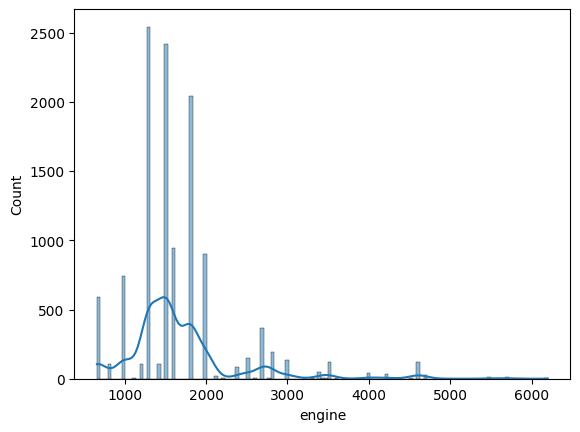

In [48]:
sns.histplot((df['engine']),kde=True)

# Removed the one outlier car which had cc of 100 and remaiing cars which have big cc are SUVS or cars who have v8 engine

In [51]:
df.head(1)

,year,price,Km_travelled,fuel_type,transmission,city,color,assembly,engine,body_type,interior_scores,exterior_scores,safety_scores,comfort_scores,company
0,2020,0.64,50000,Petrol,Automatic,Karachi,White,Imported,2000.0,Crossover,34.0,30.0,38.0,42.0,KIA


# Price

In [53]:
df['price'].describe()

,price
count,11917.000000
mean,0.626263
std,0.725911
min,0.020000
25%,0.300000
50%,0.470000
75%,0.670000
max,13.500000


In [54]:
df['price'].skew()

np.float64(5.43619438414214)

<Axes: xlabel='price', ylabel='Count'>

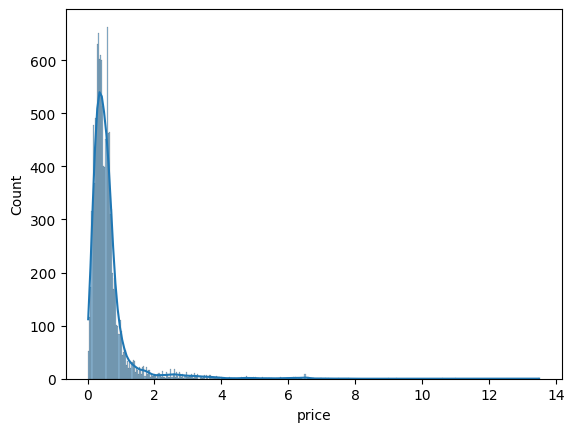

In [52]:
sns.histplot((df['price']),kde=True)

In [55]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1  - iqr * 1.5
upper_bound = q3  + iqr * 1.5

In [68]:
df_outliers = df[(df['price'] < lower_bound) |  (df['price'] > upper_bound)]
pd.crosstab(index=df_outliers['company'], columns=df_outliers['body_type'], values=df_outliers['price'], aggfunc='mean')

body_type,Compact SUV,Crossover,MPV,SUV,Sedan,Station Wagon
company,,,,,,
Audi,NaN,NaN,NaN,1.996667,1.472692,NaN
BMW,NaN,3.57500,NaN,NaN,2.626000,NaN
Haval,NaN,NaN,NaN,1.300455,NaN,NaN
Honda,NaN,1.24000,NaN,NaN,1.240000,NaN
Hummer,NaN,NaN,NaN,2.600000,NaN,NaN
Hyundai,NaN,1.25125,NaN,1.331333,1.684444,NaN
Jeep,NaN,NaN,NaN,2.475000,NaN,NaN
KIA,1.455,NaN,1.61,1.653000,NaN,NaN
Lexus,NaN,NaN,NaN,6.777143,NaN,NaN


In [69]:
df[(df['price'] < lower_bound) |  (df['price'] > upper_bound)]['body_type'].value_counts()

,count
body_type,
SUV,721
Sedan,125
Crossover,13
MPV,4
Compact SUV,2
Station Wagon,1


the price is justifiable and the expensive brands like lexus have expensive cars and most of cars are suv